# Module 14: Data Ethics & Communication
## Objective: Mastering the social and professional responsibilities of a Data Scientist.

Technical skill is only half the battle. In this final module, we learn how to 
detect bias in our datasets, protect the privacy of our subjects, and 
effectively communicate our findings to non-technical leadership.

### 1. Auditing for Fairness
We use descriptive statistics to check if our dataset is "balanced." An imbalanced 
dataset leads to a biased model.

**Scenario**: An AI system for approving agricultural loans.

Dataset Representation by Gender:
Male      83.333333
Female    16.666667
Name: Gender, dtype: float64


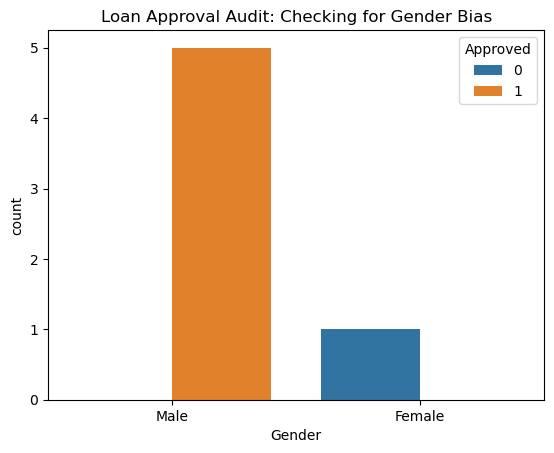

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Data: Loan Applications
data = {
    'District': ['Peshawar', 'Peshawar', 'Mardan', 'Mardan', 'Swat', 'Peshawar'],
    'Gender': ['Male', 'Male', 'Male', 'Female', 'Male', 'Male'],
    'Approved': [1, 1, 1, 0, 1, 1]
}
df = pd.DataFrame(data)

# Audit: Check the representation of Gender
representation = df['Gender'].value_counts(normalize=True) * 100
print("Dataset Representation by Gender:")
print(representation)

# Visualization of the Bias
sns.countplot(data=df, x='Gender', hue='Approved')
plt.title("Loan Approval Audit: Checking for Gender Bias")
plt.show()

if representation['Female'] < 20:
    print("WARNING: High risk of Gender Bias due to under-representation.")

### 2. Protecting Privacy (Anonymization)
Before sharing data with other departments, we must strip out "Personally 
Identifiable Information" (PII). We use hashing or masking for this.

In [2]:
import hashlib

def anonymize_email(email):
    # Masking: Only show the first letter and domain
    parts = email.split('@')
    masked = parts[0][0] + "****" + "@" + parts[1]
    return masked

def hash_id(id_number):
    # One-way Hash: Converts '12345' into a random-looking string
    return hashlib.sha256(str(id_number).encode()).hexdigest()[:10]

# Sample Patient Data
patients = pd.DataFrame({
    'Name': ['Zaryab Khan', 'Hamza Ali'],
    'Email': ['zaryab@example.com', 'hamza@example.com'],
    'Health_ID': [998877, 445566]
})

# Apply Anonymization
patients['Email'] = patients['Email'].apply(anonymize_email)
patients['Health_ID'] = patients['Health_ID'].apply(hash_id)

# Drop the 'Name' column entirely before sharing
anonymized_df = patients.drop(columns=['Name'])

print("Anonymized Dataset (Safe to Share):")
display(anonymized_df)

Anonymized Dataset (Safe to Share):


,Email,Health_ID
0,z****@example.com,c7e9988d0a
1,h****@example.com,48e6f95853


### 3. The Executive Pitch Template
When presenting your Final Boss project (Task 10), follow this structure in 
your Markdown cells or slides:

1. **The Problem**: "KPK farmers lose 20% of yield due to late rainfall alerts."
2. **The Solution**: "We built an interactive dashboard that predicts harvest windows."
3. **The Proof**: (Insert your Plotly Chart here).
4. **The Impact**: "Implementing this could save 50 million PKR in annual losses."

### Student Exercise: The Ethical Auditor
**Goal**: Perform a privacy and bias check on a "Public Health" dataset.
1. Create a DataFrame with 20 rows containing:
    - **Patient_Name** (Full Names).
    - **Ethnicity** (Purposely make it 90% one group).
    - **Treatment_Success** (Binary 1 or 0).
2. **Anonymize**: Write a function to hash the Patient_Name and delete the original column.
3. **Audit**: Calculate the percentage of each Ethnicity. Identify if the success 
   rate for the minority group is significantly different.
4. **Pitch**: Write a 3-sentence "Executive Pitch" explaining why the data 
   collection process needs to be more diverse.